In [1]:
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import spectrogram
from scipy.ndimage import gaussian_filter1d
from scipy.signal import convolve
from scipy.signal import find_peaks
import random
from scipy.signal import savgol_filter

In [2]:
CONTEXT = 100

class Pipeline:

    d = None
    d_left = None
    
    x_diff = None
    y_diff = None

    x_mask = None
    y_mask = None
    mask= None

    saccade_signals = None
    saccade_gen = None
    saccade_seq = None
    
    
    def __init__(self, t, x, y, x_left, y_left):
        self.t = t
        self.x = x
        self.y = y
        self.x_left = x_left
        self.y_left = y_left

    def run(self):
        
        (
        self.t,
        self.x,
        self.y,
        self.x_left,
        self.y_left
        ) = self.__drop_nans_with_context(self.t, self.x, self.y, self.x_left, self.y_left, context_size=5)
        
        self.t = self.__normalization_min_max_positive(self.t)
        self.x = self.__normalization_min_max(self.x)
        self.y = self.__normalization_min_max(self.y)
        self.x_left = self.__normalization_min_max(self.x_left)
        self.y_left = self.__normalization_min_max(self.y_left)

        self.d = self.__calculate_distance(self.x, self.y)
        self.d_left = self.__calculate_distance(self.x_left, self.y_left)
        
        self.__calculate_diff()
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)
        
        self.x_diff = self.__highpass_filtering(self.x_diff)
        self.y_diff = self.__highpass_filtering(self.y_diff)
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__smooth_signal(self.x_diff)
        self.y_diff = self.__smooth_signal(self.y_diff)

        self.x_diff = self.__highligth_peaks(self.x_diff)
        self.y_diff = self.__highligth_peaks(self.y_diff)

        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__lowpass_filtering(self.x_diff)
        self.y_diff = self.__lowpass_filtering(self.y_diff)
        
        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__zero_outliers(self.x_diff)
        self.y_diff = self.__zero_outliers(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_mask = self.__detect_peaks(self.x_diff, prominence=0.05, distance=10)
        self.y_mask = self.__detect_peaks(self.y_diff, prominence=0.05, distance=10)

        # self.__plot_results()

        self.d = self.__normalization_min_max_positive(self.d)
        self.d_left = self.__normalization_min_max_positive(self.d_left)
        
        self.mask = self.__contextual_dot_product(self.x_mask, self.y_mask, context=10)

        self.x = self.__normalization_min_max_positive(self.x)
        self.y = self.__normalization_min_max_positive(self.y)
        self.x_left = self.__normalization_min_max_positive(self.x_left)
        self.y_left = self.__normalization_min_max_positive(self.y_left)
        
        x_saccade = self.__extract_peak_segments(self.x, self.mask, context_size=CONTEXT)
        y_saccade = self.__extract_peak_segments(self.y, self.mask, context_size=CONTEXT)
        x_left_saccade = self.__extract_peak_segments(self.x_left, self.mask, context_size=CONTEXT)
        y_left_saccade = self.__extract_peak_segments(self.y_left, self.mask, context_size=CONTEXT)
        d_saccade = self.__extract_peak_segments(self.d, self.mask, context_size=CONTEXT)
        d_left_saccade = self.__extract_peak_segments(self.d_left, self.mask, context_size=CONTEXT)
        
        return y_saccade, y_saccade, y_saccade, y_saccade, y_saccade, y_saccade,

    def __drop_nans_with_context(self, *signals, context_size=10):
        assert len(signals) > 0, "At least one signal must be provided."
    
        signals = [pd.Series(sig).reset_index(drop=True) if not isinstance(sig, pd.Series) else sig.reset_index(drop=True) for sig in signals]
        nan_indices = np.unique(np.concatenate([
            sig[sig.isna() | (sig == "nan")].index for sig in signals
        ]))
    
        if len(nan_indices) == 0:
            return signals

        expanded_indices = np.unique(np.concatenate([
            np.arange(max(0, idx - context_size), min(len(signals[0]), idx + context_size + 1))
            for idx in nan_indices
        ]))
    
        filtered_signals = [sig.drop(expanded_indices).reset_index(drop=True) for sig in signals]
    
        filtered_signals = [sig.dropna().reset_index(drop=True) for sig in filtered_signals]
    
        min_length = min(map(len, filtered_signals))
        filtered_signals = [sig.iloc[:min_length].reset_index(drop=True) for sig in filtered_signals]
    
        return tuple(filtered_signals)

    def __calculate_distance(self, x, y):
        return np.sqrt(np.power(x, 2) + np.power(y, 2))
        
    def __calculate_diff(self):
        self.x_diff = abs(self.x - self.x_left)
        self.y_diff = abs(self.y - self.y_left)

    def __normalization_min_max_positive(self, signal):
        return (signal - signal.min()) / (signal.max() - signal.min())

    def __normalization_min_max(self, signal):
        return 2*((signal - signal.min()) / (signal.max() - signal.min())) - 1

    def __strech_signal(self, signal):
        power = 2
        mean = signal.mean()
        
        signal = np.power(signal, power)
        signal = signal / signal.mean() * mean

        return signal

    def __highpass_filtering(self, signal):
        def highpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='high', analog=False)  # Change to 'high'
            return filtfilt(b, a, data)

        return highpass_filter(signal)

    def __smooth_signal(self, signal, sigma=5):
        return gaussian_filter1d(signal, sigma=sigma)

    def __highligth_peaks(self,signal):
        difference_kernel = np.array([-1,-1, 0, 1,1]) 
        return convolve(signal, difference_kernel, mode="same")

    def __lowpass_filtering(self, signal):
        def lowpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='low', analog=False)
            return filtfilt(b, a, data)

        return lowpass_filter(signal)

    def __zero_outliers(self, signal):
        Q1 = np.percentile(signal, 5) 
        Q3 = np.percentile(signal, 95)
        IQR = Q3 - Q1
        
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        filtered_signal = signal.copy()
        filtered_signal[(filtered_signal < lower) | (filtered_signal > upper)] = 0
    
        return filtered_signal

    def __detect_peaks(self, signal, height=None, prominence=0.1, distance=5):
        signal = np.array(signal)
        peaks, _ = find_peaks(signal, height=height, prominence=prominence, distance=distance)
        peak_mask = np.zeros(len(signal), dtype=int)
        peak_mask[peaks] = 1
        
        return peak_mask

    def __plot_results(self):

        start = 32498
        end = start + 200
        
        fig, axes = plt.subplots(6, 1, figsize=(8, 8), sharex=True)
        
        axes[0].plot(self.t.iloc[start:end], self.x.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[0].set_ylabel("X Position Rigth Eye")
        axes[0].set_title("X vs Time")
        axes[0].grid(True)
        
        axes[1].plot(self.t.iloc[start:end], self.x_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[1].set_xlabel("Time (Normalized)")
        axes[1].set_ylabel("X Position Left Eye")
        axes[1].set_title("X vs Time")
        axes[1].grid(True)
        
        axes[2].plot(self.t.iloc[start:end], self.x_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[2].set_xlabel("Time (Normalized)")
        axes[2].set_ylabel("X Diffrence")
        axes[2].set_title("saccade movement")
        axes[2].grid(True)

        axes[3].plot(self.t.iloc[start:end], self.y.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[3].set_ylabel("X Position Rigth Eye")
        axes[3].set_title("Y vs Time")
        axes[3].grid(True)
        
        axes[4].plot(self.t.iloc[start:end], self.y_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[4].set_xlabel("Time (Normalized)")
        axes[4].set_ylabel("X Position Left Eye")
        axes[4].set_title("Y vs Time")
        axes[4].grid(True)
        
        axes[5].plot(self.t.iloc[start:end], self.y_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[5].set_xlabel("Time (Normalized)")
        axes[5].set_ylabel("X Diffrence")
        axes[5].set_title("saccade movement")
        axes[5].grid(True)
        
        plt.tight_layout()
        plt.show()

    def __extract_peak_segments(self, signal, mask, context_size=5):
        signal = np.array(signal)
        mask = np.array(mask)
    
        assert len(signal) == len(mask), "Signal and mask must have the same length."
    
        extracted_segments = []
        peak_indices = np.where(mask == 1)[0]
    
        for idx in peak_indices:
            start = max(0, idx - context_size)
            end = min(len(signal), idx + context_size + 1)
            
            extracted_segments.append(signal[start:end])
        return extracted_segments

    def __generate_smoothed_signal(self, fragments):
        if not fragments:
            return
        random.shuffle(fragments)
        smoothed_signal = [fragments[0]]
    
        last_value = fragments[0][-1]
    
        for i in range(1, len(fragments)):
            shift = last_value - fragments[i][0]
            translated_fragment = fragments[i] + shift
    
            smoothed_signal.append(translated_fragment)
            last_value = translated_fragment[-1]

        yield np.concatenate(smoothed_signal)

    def __savgol_filter(self, signal):
        return savgol_filter(signal, window_length=11, polyorder=3)
    
    def __idt(self, x, y, t, velocity_threshold=30):
        dx = np.diff(x)
        dy = np.diff(y)
        dt = np.diff(t)
    
        velocity = np.sqrt(dx**2 + dy**2) / dt  
        velocity = np.insert(velocity, 0, 0)
    
        saccade_mask = velocity > velocity_threshold
        saccade_mask = saccade_mask.astype(int)
    
        return saccade_mask
    
    def __contextual_dot_product(self, signal1, signal2, context):
        assert len(signal1) == len(signal2), "Signals must be of equal length"
    
        # Create a kernel with ones in the given context range
        kernel = np.ones(2 * context + 1)
    
        # Convolve signal2 with the kernel (this spreads 1s over the context)
        spread_signal2 = convolve(signal2, kernel, mode='same')  # 'same' keeps original size
    
        # Convert convolved signal to binary (any nonzero value means a 1 was nearby)
        spread_signal2 = (spread_signal2 > 0).astype(int)
    
        # Perform element-wise AND (dot product-like)
        result = signal1 * spread_signal2
        return result
    




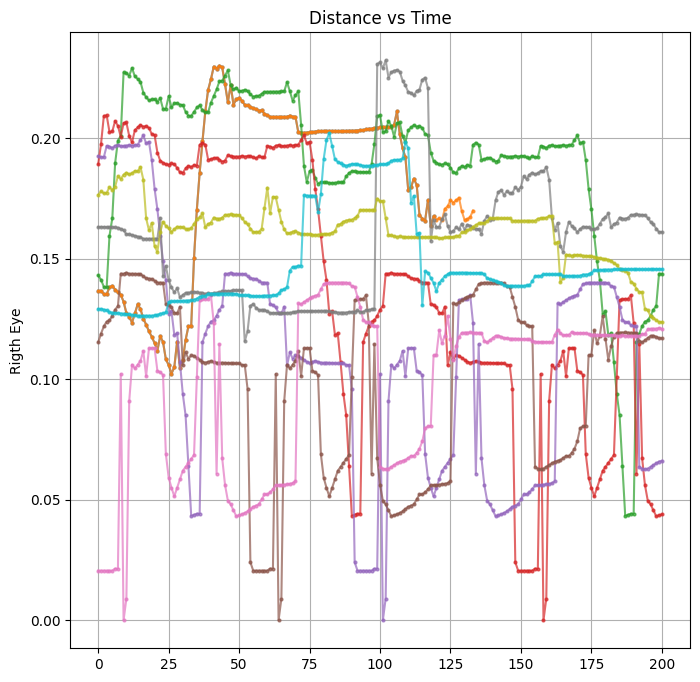

In [3]:
file_path = "../data/00/data.csv"
df = pd.read_csv(file_path)

selected_columns = ["t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
                    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"]
df = df[selected_columns]

df = df.rename(columns={
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
})

pipeline = Pipeline(df["t"], df["x"], df["y"], df["x_left"], df["y_left"])
saccade_signals = pipeline.run()

num_features = len(saccade_signals)

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

for signal in saccade_signals[3][:10]:
    axes.plot(signal, marker='o', linestyle='-', markersize=2, alpha=0.7)
axes.set_ylabel("Rigth Eye")
axes.set_title("Distance vs Time")
axes.grid(True)

# print(len(saccade_seq))

In [4]:
labels = [0, 1, 9, 5] # 9, 11 [0, 1, 9, 5] -> 62%(66% dla random forest)(80% przy CONTEXT = 100) [51, 7] -> 60%
labels_num = len(labels)

In [5]:
import pandas as pd

# Selected columns to read from each CSV file
selected_columns = [
    "t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"
]

# Renaming dictionary (base names)
rename_dict = {
    "t": "t", 
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
}

# List to store all DataFrames
df_list = []

# Load each CSV file and process it
for i in labels:  # Loop from 00 to 09
    file_path = f"../data/{i:02d}/data.csv"  # Format path dynamically
    
    # Load CSV, only select needed columns
    df = pd.read_csv(file_path, usecols=selected_columns)
    
    # Trim to 100,000 rows
    df = df.iloc[:100000]
    
    # Rename columns with appropriate suffix
    df = df.rename(columns={col: f"{rename_dict[col]}{i:02d}" for col in selected_columns})
    
    # Append processed DataFrame to the list
    df_list.append(df)

# Concatenate all DataFrames side-by-side
merged_df = pd.concat(df_list, axis=1)

merged_df.head()


,t00,x00,y00,x_left00,y_left00,t01,x01,y01,x_left01,y_left01,t05,x05,y05,x_left05,y_left05
0,1.581362e+15,-29.585846,1.740021,32.436142,5.695251,1.583335e+15,-33.649307,0.915329,29.914169,4.788696,1.583342e+15,-29.673431,9.661453,28.812241,8.266678
1,1.581362e+15,-29.591797,1.740555,32.421951,5.614624,1.583335e+15,-33.651520,0.925964,29.914185,4.745239,1.583342e+15,-29.652618,9.693024,28.845490,8.338638
2,1.581362e+15,-29.599228,1.711990,32.406448,5.580765,1.583335e+15,-33.654449,0.910370,29.913483,4.757553,1.583342e+15,-29.622772,9.761322,28.873566,8.422882
3,1.581362e+15,-29.606445,1.710693,32.386810,5.647583,1.583335e+15,-33.655487,0.906570,29.913757,4.726425,1.583342e+15,-29.615051,9.714996,28.894241,8.364700
4,1.581362e+15,-29.615341,1.769791,32.370270,5.730347,1.583335e+15,-33.656067,0.902786,29.921448,4.677521,1.583342e+15,-29.616058,9.767410,28.915497,8.398773


In [6]:
import pandas as pd
import numpy as np

# List of signal types to extract
signal_types = ["t", "x", "y", "x_left", "y_left"]

# Create an empty list to store instances
instances = []

_, labels_norm = np.unique(labels, return_inverse=True)
# Iterate over the 10 labels (00 to 09)
for i, label in zip(labels, labels_norm):  
    
    for signal_type in signal_types:  # Iterate over all signal types
        signal = merged_df[f"{signal_type}{i:02d}"]  # Extract the correct column
        
        # Split the signal into 10 segments of 10,000 each
        for j in range(10):
            segment = signal[j * 10000 : (j + 1) * 10000].values  # Extract 10,000-length segment
            
            # Create a row with label, signal type, segment number, and signal values
            instance = [label, signal_type, j + 1] + list(segment)  # j+1 to start segments from 1
            
            # Store instance
            instances.append(instance)

# Define column names
columns = ["label", "signal_type", "segment"] + [f"dim_{i}" for i in range(10000)]

# Convert list to DataFrame
df_processed = pd.DataFrame(instances, columns=columns)

df_processed.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [7]:
df_train_raw = df_processed[df_processed["segment"].between(1, 6)]
df_val_raw = df_processed[df_processed["segment"].between(7,8)]
df_test_raw = df_processed[df_processed["segment"].between(9, 10)]

In [8]:
df_train_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [9]:
df_test_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
8,0,t,9,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
9,0,t,10,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
18,0,x,9,-2.990927e+01,-2.998026e+01,-3.002446e+01,-3.001945e+01,-3.001668e+01,-3.001811e+01,-3.003775e+01,...,-3.049767e+01,-3.049767e+01,-3.049767e+01,-3.049771e+01,-3.049779e+01,-3.049789e+01,-3.048491e+01,-3.037790e+01,-3.016847e+01,-2.997070e+01
19,0,x,10,-2.991096e+01,-2.991100e+01,-2.993440e+01,-2.994386e+01,-2.993948e+01,-2.993697e+01,-2.993445e+01,...,-3.110291e+01,-3.115651e+01,-3.117418e+01,-3.118117e+01,-3.120784e+01,-3.121338e+01,-3.121408e+01,-3.121478e+01,-3.121684e+01,-3.121889e+01
28,0,y,9,4.440231e+00,4.467010e+00,4.447861e+00,4.524704e+00,4.523743e+00,4.494003e+00,4.359497e+00,...,3.703949e+00,3.703949e+00,3.703949e+00,3.702026e+00,3.701538e+00,3.701096e+00,3.720657e+00,3.821564e+00,3.790878e+00,3.927002e+00


In [10]:
df_val_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
6,0,t,7,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
7,0,t,8,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
16,0,x,7,-2.964194e+01,-2.963448e+01,-2.966989e+01,-2.967346e+01,-2.967860e+01,-2.967662e+01,-2.967274e+01,...,-2.988069e+01,-2.988994e+01,-2.988834e+01,-2.988745e+01,-2.988666e+01,-2.988661e+01,-2.988655e+01,-2.988615e+01,-2.988655e+01,-2.988634e+01
17,0,x,8,-2.988655e+01,-2.988634e+01,-2.988655e+01,-2.988661e+01,-2.988666e+01,-2.988678e+01,-2.988690e+01,...,-2.988496e+01,-2.988054e+01,-2.987500e+01,-2.988220e+01,-2.986838e+01,-2.987280e+01,-2.985788e+01,-2.986806e+01,-2.986948e+01,-2.987563e+01
26,0,y,7,4.521317e+00,4.422272e+00,4.166809e+00,4.100616e+00,4.008209e+00,4.072952e+00,4.102341e+00,...,3.152298e+00,3.182236e+00,3.212982e+00,3.208160e+00,3.212982e+00,3.213165e+00,3.213364e+00,3.213715e+00,3.214081e+00,3.214233e+00


# features generation

In [11]:
def generate_features(df):
    generated_signals = []
    generated_labels = []
    
    # Iterate over unique labels
    for label in df["label"].unique():
        df_label = df[df["label"] == label]
    
        # Iterate over unique segments
        for segment in df_label["segment"].unique():
            df_segment = df_label[df_label["segment"] == segment]
    
            # Extract input signals for the pipeline based on signal_type
            t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
    
            # Run the pipeline 10 times for each segment
            # for _ in range(10):
            pipeline = Pipeline(t, x, y, x_left, y_left)
            results = pipeline.run()
            
            # Store the generated signal and label
            for result in results:
                generated_signals.extend(result)
                generated_labels.extend([label]*len(result))
    
    # Convert results into DataFrame
    return pd.DataFrame(generated_signals), pd.DataFrame({"label": generated_labels})

df_train, df_train_labels = generate_features(df_train_raw)
# df_train = df_train.iloc[:, :1000]

df_test, df_test_labels = generate_features(df_test_raw)
# df_test = df_test.iloc[:, :1000]

df_val, df_val_labels = generate_features(df_val_raw)
# df_val = df_val.iloc[:, :1000]

In [12]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,200
0,0.453436,0.453519,0.449067,0.448865,0.458076,0.460345,0.455177,0.451357,0.448258,0.438379,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.453436,0.453519,0.449067,0.448865,0.458076,0.460345,0.455177,0.451357,0.448258,0.438379,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.451357,0.448258,0.438379,0.422777,0.417528,0.409751,0.422233,0.434795,0.428347,0.415178,...,0.749539,0.756655,0.736282,0.730498,0.733015,0.728225,0.728741,0.730151,0.728479,0.723708
3,0.692819,0.692816,0.692759,0.692816,0.692873,0.692933,0.694619,0.692933,0.692873,0.671623,...,0.694933,0.671968,0.672922,0.687182,0.680487,0.665456,0.684297,0.685089,0.666545,0.657784
4,0.566382,0.569757,0.578179,0.574875,0.577898,0.581606,0.563210,0.550923,0.552105,0.555050,...,0.653928,0.652292,0.652770,0.653246,0.653976,0.653246,0.653976,0.654708,0.660792,0.667440


In [13]:
df_train = df_train.fillna(df_train.mean())
df_test = df_test.fillna(df_test.mean())
df_val = df_val.fillna(df_val.mean())

In [14]:
df_train.isna().sum().sum()

np.int64(0)

In [15]:
df_train_labels.head()

,label
0,0
1,0
2,0
3,0
4,0


In [16]:
df_test.head()

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,200
0,0.751103,0.758782,0.753290,0.775326,0.775050,0.766522,0.727952,0.733640,0.687456,0.678014,...,0.409230,0.408325,0.409133,0.409501,0.410330,0.409214,0.408267,0.408872,0.407313,0.409539
1,0.587546,0.584124,0.585900,0.585625,0.587935,0.590429,0.587357,0.586377,0.582382,0.578392,...,0.402618,0.403380,0.402618,0.402505,0.402391,0.397757,0.393123,0.393123,0.393123,0.393123
2,0.868905,0.871911,0.867982,0.866188,0.860775,0.804703,0.888709,0.768828,0.589357,0.492566,...,0.137917,0.137155,0.138179,0.137155,0.136893,0.137155,0.137155,0.137155,0.137155,0.137155
3,0.592512,0.598134,0.603000,0.601967,0.595050,0.596848,0.602435,0.612657,0.622383,0.622690,...,0.817191,0.781998,0.742185,0.794547,0.775829,0.777041,0.767095,0.776266,0.781884,0.774315
4,0.629660,0.627822,0.628584,0.628899,0.625971,0.632206,0.634066,0.633703,0.628229,0.635129,...,0.758874,0.760029,0.764304,0.766588,0.767209,0.767051,0.765192,0.766290,0.768627,0.779264


In [17]:
df_test_labels.head()

,label
0,0
1,0
2,0
3,0
4,0


In [18]:
def shuffle_dataframe_grouped(df, df_labels, group_size=4, random_state=42):
    # Step 1: Compute group indices (every 4 rows are one group)
    num_groups = len(df) // group_size
    group_indices = np.arange(num_groups)

    # Step 2: Shuffle group indices
    np.random.seed(random_state)
    np.random.shuffle(group_indices)

    # Step 3: Reconstruct dataframe and labels in shuffled order
    shuffled_df = pd.concat([df.iloc[i * group_size : (i + 1) * group_size] for i in group_indices]).reset_index(drop=True)
    shuffled_labels = pd.concat([df_labels.iloc[i * group_size : (i + 1) * group_size] for i in group_indices]).reset_index(drop=True)

    return shuffled_df, shuffled_labels

# Apply to train, test, and validation sets
df_train, df_train_labels = shuffle_dataframe_grouped(df_train, df_train_labels, group_size=num_features)
df_test, df_test_labels = shuffle_dataframe_grouped(df_test, df_test_labels, group_size=num_features)
df_val, df_val_labels = shuffle_dataframe_grouped(df_val, df_val_labels, group_size=num_features)

# Machine Learning

## Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [20]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Ensure num_rows is a multiple of num_features
assert df_train.shape[0] % num_features == 0, f"Number of rows in df_train is not a multiple of {num_features}!"
assert df_test.shape[0] % num_features == 0, f"Number of rows in df_test is not a multiple of {num_features}!"

# Convert DataFrames to NumPy arrays
X_train = df_train.values
X_test = df_test.values
y_train = df_train_labels["label"].values
y_test = df_test_labels["label"].values

# Get original feature count per row
num_features_per_row = X_train.shape[1]  # Each row has `num_features_per_row` features

# Reshape: Group every 4 rows into a single sample
X_train_reshaped = X_train.reshape(-1, num_features_per_row * num_features)  # (num_samples, num_features)
X_test_reshaped = X_test.reshape(-1, num_features_per_row * num_features)  # (num_samples, num_features)

# Adjust Labels: Keep only every 4th label (assuming labels are duplicated for each row in a group)
y_train_reshaped = y_train[::num_features]
y_test_reshaped = y_test[::num_features]

# Verify Shapes
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")  # Expected: (num_samples, num_features_per_sample)
print(f"y_train_reshaped shape: {y_train_reshaped.shape}")  # Expected: (num_samples,)

# Train Random Forest Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_reshaped, y_train_reshaped)

# Predict
y_pred = clf.predict(X_test_reshaped)

# Evaluate Performance
accuracy = accuracy_score(y_test_reshaped, y_pred)
report = classification_report(y_test_reshaped, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)


X_train_reshaped shape: (434, 1206)
y_train_reshaped shape: (434,)
Test Accuracy: 0.6400
Classification Report:
               precision    recall  f1-score   support

           0       0.27      0.30      0.29        30
           1       0.69      0.45      0.55        44
           2       0.81      1.00      0.89        51

    accuracy                           0.64       125
   macro avg       0.59      0.58      0.58       125
weighted avg       0.64      0.64      0.63       125



as expected classical machine learning algorithms are failing (or are they)

## Deep Learning

In [21]:
import torch
import numpy as np
import random

def set_seed(seed=0):
    torch.manual_seed(seed)  # Sets PyTorch seed (CPU)
    torch.cuda.manual_seed(seed)  # Sets PyTorch seed (GPU)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    np.random.seed(seed)  # Sets NumPy seed
    random.seed(seed)  # Sets Python random seed

    torch.backends.cudnn.deterministic = True  # Ensures deterministic behavior
    torch.backends.cudnn.benchmark = False  # Disables cuDNN optimization for reproducibility

set_seed(0)  # Set seed to 0

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
# mini CNN

neurons = [256,512,1024,2048]
# neurons = [2048,1024,512,256]

class NN(nn.Module):
    def __init__(self, num_classes):
        super(NN, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=neurons[0], kernel_size=8, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(neurons[0])

        self.conv2 = nn.Conv1d(neurons[0], neurons[1], kernel_size=8, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(neurons[1])

        self.conv3 = nn.Conv1d(neurons[1], neurons[2], kernel_size=4, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(neurons[2])
        
        # Pooling and Dropout Layers
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(0.05)
        # self.dropout2 = nn.Dropout(0.4)

        # Adaptive Pooling to keep FC layer input size fixed
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(neurons[2], neurons[3])
        self.fc2 = nn.Linear(neurons[3], num_classes)

    def forward(self, x):
        x = nn.ReLU()(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = nn.ReLU()(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = nn.ReLU()(self.bn3(self.conv3(x)))
        x = self.pool(x)
        
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        # x = x.squeeze(-1)

        x = nn.ReLU()(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        # self.dropout2(x)
        
        return x

In [24]:
X_train = df_train.values.astype(np.float32)
y_train = df_train_labels["label"].values[::num_features].astype(np.int64)

X_val = df_val.values.astype(np.float32)
y_val = df_val_labels["label"].values[::num_features].astype(np.int64)

X_test = df_test.values.astype(np.float32)
y_test = df_test_labels["label"].values[::num_features].astype(np.int64)

# ✅ Ensure correct shape: (num_samples, 4 features, sequence_length)
sequence_length = 2 * CONTEXT + 1  # Each sample consists of `sequence_length` timestamps
num_features = num_features  # 4 Features per timestamp

X_train = X_train.reshape(-1, num_features, sequence_length)  # ✅ Now shape is (num_samples, 4, sequence_length)
X_val = X_val.reshape(-1, num_features, sequence_length)
X_test = X_test.reshape(-1, num_features, sequence_length)

print(X_train.shape)
print(y_train.shape)
print(np.unique(y_train))

# Define PyTorch Dataset
class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)  # No unsqueeze(1), we now have multiple features per timestamp
        self.y = torch.tensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataloaders
train_dataset = SignalDataset(X_train, y_train)
test_dataset = SignalDataset(X_test, y_test)
val_dataset = SignalDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Checking for NaNs in dataset...")
print(f"NaNs in X_train: {np.isnan(X_train).sum()}, NaNs in y_train: {np.isnan(y_train).sum()}")
print(f"Infs in X_train: {np.isinf(X_train).sum()}, Infs in y_train: {np.isinf(y_train).sum()}")


(434, 6, 201)
(434,)
[0 1 2]
Checking for NaNs in dataset...
NaNs in X_train: 0, NaNs in y_train: 0
Infs in X_train: 0, Infs in y_train: 0


Checking for NaNs in dataset...
NaNs in X_train: 0, NaNs in y_train: 0
Infs in X_train: 0, Infs in y_train: 0
Epoch 1/10, Loss: 8.9886, Accuracy: 69.82%
Epoch 2/10, Loss: 6.4371, Accuracy: 79.03%
Epoch 3/10, Loss: 6.6614, Accuracy: 79.03%
Epoch 4/10, Loss: 5.7628, Accuracy: 81.80%
Epoch 5/10, Loss: 4.9481, Accuracy: 82.72%
Epoch 6/10, Loss: 4.5304, Accuracy: 86.87%
Epoch 7/10, Loss: 5.2423, Accuracy: 83.64%
Epoch 8/10, Loss: 5.0222, Accuracy: 84.56%
Epoch 9/10, Loss: 5.4659, Accuracy: 83.41%
Epoch 10/10, Loss: 4.3452, Accuracy: 84.10%
Test Accuracy: 77.60%

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.40      0.46        30
           1       0.92      0.77      0.84        44
           2       0.77      1.00      0.87        51

    accuracy                           0.78       125
   macro avg       0.75      0.72      0.72       125
weighted avg       0.77      0.78      0.76       125



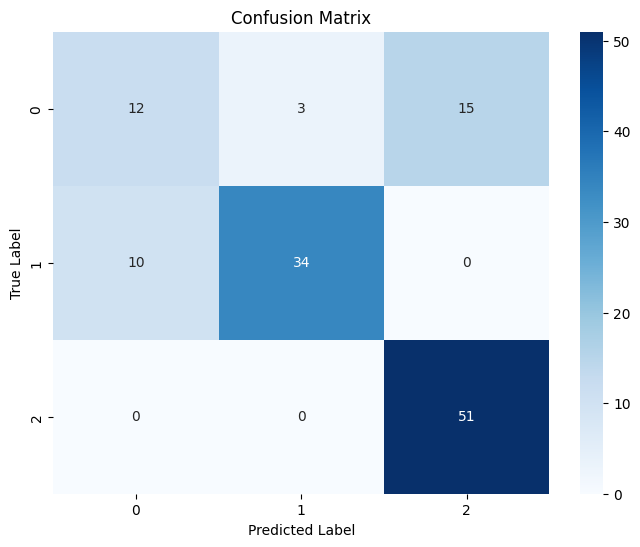

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model
model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

print("Checking for NaNs in dataset...")
print(f"NaNs in X_train: {np.isnan(X_train).sum()}, NaNs in y_train: {np.isnan(y_train).sum()}")
print(f"Infs in X_train: {np.isinf(X_train).sum()}, Infs in y_train: {np.isinf(y_train).sum()}")


# Training Loop
def train_model(model, train_loader, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Train Model
train_model(model, train_loader, num_epochs=10)

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Test the model and show confusion matrix
evaluate_model(model, test_loader)


Epoch 1/50 - Loss: 8.7793 - Train Acc: 69.59% - Val AUC-ROC: 0.8914
✅ New Best Model Saved! AUC-ROC: 0.8914
Epoch 2/50 - Loss: 7.1522 - Train Acc: 76.73% - Val AUC-ROC: 0.9328
✅ New Best Model Saved! AUC-ROC: 0.9328
Epoch 3/50 - Loss: 6.1060 - Train Acc: 81.11% - Val AUC-ROC: 0.9406
✅ New Best Model Saved! AUC-ROC: 0.9406
Epoch 4/50 - Loss: 5.8772 - Train Acc: 81.11% - Val AUC-ROC: 0.9434
✅ New Best Model Saved! AUC-ROC: 0.9434
Epoch 5/50 - Loss: 4.7823 - Train Acc: 85.25% - Val AUC-ROC: 0.9509
✅ New Best Model Saved! AUC-ROC: 0.9509
Epoch 6/50 - Loss: 4.7735 - Train Acc: 84.10% - Val AUC-ROC: 0.8673
⏳ Early Stopping Counter: 1/5
Epoch 7/50 - Loss: 4.7688 - Train Acc: 86.41% - Val AUC-ROC: 0.9342
⏳ Early Stopping Counter: 2/5
Epoch 8/50 - Loss: 3.5958 - Train Acc: 88.71% - Val AUC-ROC: 0.9305
⏳ Early Stopping Counter: 3/5
Epoch 9/50 - Loss: 3.3453 - Train Acc: 90.55% - Val AUC-ROC: 0.9502
⏳ Early Stopping Counter: 4/5
Epoch 10/50 - Loss: 3.1000 - Train Acc: 92.17% - Val AUC-ROC: 0.9377

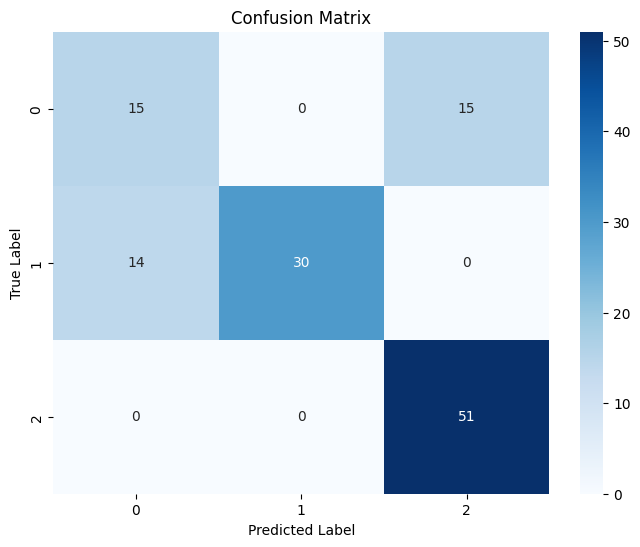

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from torch.utils.data import Dataset, DataLoader

# Model Setup
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# Training with Early Stopping & AUC-ROC Monitoring
def train_model(model, train_loader, val_loader, num_epochs=50, patience=5):
    best_auc_roc = 0.0
    patience_counter = 0
    best_model_path = "best_model.pth"

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_accuracy = 100 * correct / total
        val_auc_roc = evaluate_auc_roc(model, val_loader, num_classes)  # Compute AUC-ROC

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss:.4f} - Train Acc: {train_accuracy:.2f}% - Val AUC-ROC: {val_auc_roc:.4f}")

        # Early Stopping Logic
        if val_auc_roc > best_auc_roc:
            best_auc_roc = val_auc_roc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)  # Save Best Model
            print(f"✅ New Best Model Saved! AUC-ROC: {best_auc_roc:.4f}")
        else:
            patience_counter += 1
            print(f"⏳ Early Stopping Counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"⏹️ Early Stopping Triggered! Best AUC-ROC: {best_auc_roc:.4f}")
            break

    print("🎉 Training Complete!")

from sklearn.preprocessing import label_binarize

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np

def evaluate_auc_roc(model, val_loader, num_classes):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Ensure valid probabilities

            all_preds.extend(probabilities)
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 🔍 Debugging NaN values
    if np.isnan(all_preds).sum() > 0 or np.isnan(all_labels).sum() > 0:
        print("⚠️ Warning: NaN values detected in predictions or labels.")
        all_preds = np.nan_to_num(all_preds)  # Replace NaNs with 0
        all_labels = np.nan_to_num(all_labels)

    # Ensure at least two unique classes exist
    if len(set(all_labels)) == 1:
        print("⚠️ Warning: Only one class present in all_labels. AUC-ROC cannot be computed.")
        return 0.0

    # Compute AUC-ROC
    all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))

    try:
        if num_classes > 2:
            return roc_auc_score(all_labels_bin, all_preds, multi_class='ovo')
        else:
            return roc_auc_score(all_labels, all_preds[:, 1])  # Binary AUC-ROC
    except ValueError as e:
        print(f"❌ Error in AUC-ROC computation: {e}")
        return 0.0  # Return default value if an error occurs


# Train Model
train_model(model, train_loader, val_loader, num_epochs=50, patience=5)

# Load Best Model and Evaluate on Test Set
best_model = NN(num_classes).to(device)
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()

from sklearn.metrics import precision_recall_fscore_support

from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def evaluate_model(model, test_loader, num_classes):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)

            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Ensure valid probabilities
            _, predicted = torch.max(outputs, 1)  # Predicted class

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            all_probs.extend(probabilities)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # 🔍 Check for NaN values
    if np.isnan(all_probs).sum() > 0 or np.isnan(all_labels).sum() > 0:
        print("⚠️ Warning: NaN values detected in predictions or labels. Replacing NaNs with zeros.")
        all_probs = np.nan_to_num(all_probs)
        all_labels = np.nan_to_num(all_labels)

    # 🔍 Ensure at least two unique classes exist
    if len(set(all_labels)) == 1:
        print("⚠️ Warning: Only one class present in all_labels. AUC-ROC and multi-class metrics cannot be computed.")
        auc_roc = 0.0
    else:
        # Compute AUC-ROC
        all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))
        try:
            if num_classes > 2:
                auc_roc = roc_auc_score(all_labels_bin, all_probs, multi_class='ovo')
            else:
                auc_roc = roc_auc_score(all_labels, all_probs[:, 1])  # Binary AUC-ROC
        except ValueError as e:
            print(f"❌ Error in AUC-ROC computation: {e}")
            auc_roc = 0.0

    # Compute Accuracy
    accuracy = 100 * correct / total if total > 0 else 0.0

    # Compute Precision, Recall, F1-score for each class
    try:
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
        weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    except ValueError as e:
        print(f"❌ Error in Precision/Recall/F1 computation: {e}")
        precision, recall, f1 = [0] * num_classes, [0] * num_classes, [0] * num_classes
        macro_precision, macro_recall, macro_f1 = 0.0, 0.0, 0.0
        weighted_precision, weighted_recall, weighted_f1 = 0.0, 0.0, 0.0

    # Print evaluation results
    print(f"\n✅ Test Accuracy: {accuracy:.2f}%")
    print(f"✅ Test AUC-ROC: {auc_roc:.4f}\n")

    print(f"📊 Macro Avg - Precision: {macro_precision:.4f}, Recall: {macro_recall:.4f}, F1-score: {macro_f1:.4f}")
    print(f"📊 Weighted Avg - Precision: {weighted_precision:.4f}, Recall: {weighted_recall:.4f}, F1-score: {weighted_f1:.4f}")

    # Display Per-Class Metrics
    for i in range(num_classes):
        print(f"🔹 Class {i} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1-score: {f1[i]:.4f}")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    print("\n📌 Classification Report:\n", classification_report(all_labels, all_preds, digits=4))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


# Evaluate Best Model
evaluate_model(best_model, test_loader, num_classes)


# Dummy Pipeline

In [27]:
class DummyPipeline:

    d = None
    
    x_diff = None
    y_diff = None

    x_mask = None
    y_mask = None
    mask= None

    saccade_signals = None
    saccade_gen = None
    saccade_seq = None
    
    
    def __init__(self, t, x, y, x_left, y_left):
        self.t = t
        self.x = x
        self.y = y
        self.x_left = x_left
        self.y_left = y_left

    def run(self):
        
        (
        self.t,
        self.x,
        self.y,
        self.x_left,
        self.y_left
        ) = self.__drop_nans_with_context(self.t, self.x, self.y, self.x_left, self.y_left, context_size=5)
        
        self.t = self.__normalization_min_max_positive(self.t)
        self.x = self.__normalization_min_max_positive(self.x)
        self.y = self.__normalization_min_max_positive(self.y)
        self.x_left = self.__normalization_min_max_positive(self.x_left)
        self.y_left = self.__normalization_min_max_positive(self.y_left)

        self.mask = self.__generate_peaks(self.x, 100)

        x_saccade = self.__extract_peak_segments(self.x, self.mask, context_size=CONTEXT)
        y_saccade = self.__extract_peak_segments(self.y, self.mask, context_size=CONTEXT)
        x_left_saccade = self.__extract_peak_segments(self.x_left, self.mask, context_size=CONTEXT)
        y_left_saccade = self.__extract_peak_segments(self.y_left, self.mask, context_size=CONTEXT)
        
        return x_saccade, x_saccade, x_saccade, x_left_saccade, x_left_saccade, x_left_saccade 

    def __drop_nans_with_context(self, *signals, context_size=10):
        assert len(signals) > 0, "At least one signal must be provided."
    
        signals = [pd.Series(sig).reset_index(drop=True) if not isinstance(sig, pd.Series) else sig.reset_index(drop=True) for sig in signals]
        nan_indices = np.unique(np.concatenate([
            sig[sig.isna() | (sig == "nan")].index for sig in signals
        ]))
    
        if len(nan_indices) == 0:
            return signals

        expanded_indices = np.unique(np.concatenate([
            np.arange(max(0, idx - context_size), min(len(signals[0]), idx + context_size + 1))
            for idx in nan_indices
        ]))
    
        filtered_signals = [sig.drop(expanded_indices).reset_index(drop=True) for sig in signals]
    
        filtered_signals = [sig.dropna().reset_index(drop=True) for sig in filtered_signals]
    
        min_length = min(map(len, filtered_signals))
        filtered_signals = [sig.iloc[:min_length].reset_index(drop=True) for sig in filtered_signals]
    
        return tuple(filtered_signals)

    def __normalization_min_max_positive(self, signal):
        return (signal - signal.min()) / (signal.max() - signal.min())
        
    def __extract_peak_segments(self, signal, mask, context_size=5):
        signal = np.array(signal)
        mask = np.array(mask)
    
        assert len(signal) == len(mask), "Signal and mask must have the same length."
    
        extracted_segments = []
        peak_indices = np.where(mask == 1)[0]
    
        for idx in peak_indices:
            start = max(0, idx - context_size)
            end = min(len(signal), idx + context_size + 1)
            
            extracted_segments.append(signal[start:end])
        return extracted_segments
    
    def __generate_peaks(self, signal, num_of_peaks):
        signal_length = len(signal)
        
        # Ensure num_of_peaks is not greater than the signal length
        num_of_peaks = min(num_of_peaks, signal_length)
        
        # Create an array of zeros
        new_signal = np.zeros(signal_length, dtype=int)
        
        # Randomly choose indices to place ones
        peak_indices = np.random.choice(signal_length, num_of_peaks, replace=False)
        
        # Assign ones at the selected indices
        new_signal[peak_indices] = 1
        
        return new_signal




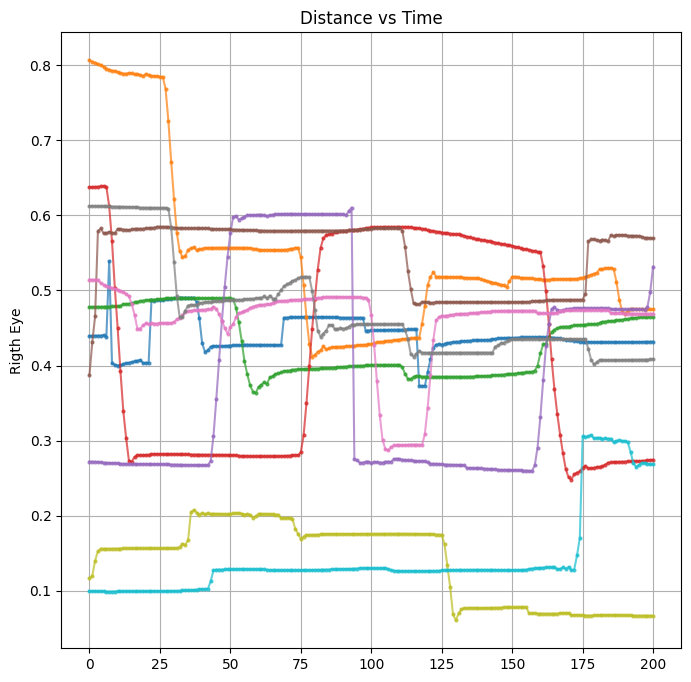

In [28]:
file_path = "../data/00/data.csv"
df = pd.read_csv(file_path)

selected_columns = ["t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
                    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"]
df = df[selected_columns]

df = df.rename(columns={
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
})

pipeline = DummyPipeline(df["t"], df["x"], df["y"], df["x_left"], df["y_left"])
saccade_signals = pipeline.run()

num_features = len(saccade_signals)

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

for signal in saccade_signals[3][:10]:
    axes.plot(signal, marker='o', linestyle='-', markersize=2, alpha=0.7)
axes.set_ylabel("Rigth Eye")
axes.set_title("Distance vs Time")
axes.grid(True)

In [29]:
def generate_features(df):
    generated_signals = []
    generated_labels = []
    
    # Iterate over unique labels
    for label in df["label"].unique():
        df_label = df[df["label"] == label]
    
        # Iterate over unique segments
        for segment in df_label["segment"].unique():
            df_segment = df_label[df_label["segment"] == segment]
    
            # Extract input signals for the pipeline based on signal_type
            t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
    
            # Run the pipeline 10 times for each segment
            # for _ in range(10):
            pipeline = DummyPipeline(t, x, y, x_left, y_left)
            results = pipeline.run()
            
            # Store the generated signal and label
            for result in results:
                valid_result = [signal for signal in result if len(signal) == 2 * CONTEXT + 1]
                generated_signals.extend(valid_result)
                generated_labels.extend([label]*len(valid_result))
    
    # Convert results into DataFrame
    return pd.DataFrame(generated_signals), pd.DataFrame({"label": generated_labels})

df_train, df_train_labels = generate_features(df_train_raw)
# df_train = df_train.iloc[:, :1000]

df_test, df_test_labels = generate_features(df_test_raw)
# df_test = df_test.iloc[:, :1000]

df_val, df_val_labels = generate_features(df_val_raw)
# df_val = df_val.iloc[:, :1000]

In [30]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Ensure num_rows is a multiple of num_features
assert df_train.shape[0] % num_features == 0, f"Number of rows in df_train is not a multiple of {num_features}!"
assert df_test.shape[0] % num_features == 0, f"Number of rows in df_test is not a multiple of {num_features}!"

# Convert DataFrames to NumPy arrays
X_train = df_train.values
X_test = df_test.values
y_train = df_train_labels["label"].values
y_test = df_test_labels["label"].values

# Get original feature count per row
num_features_per_row = X_train.shape[1]  # Each row has `num_features_per_row` features

# Reshape: Group every 4 rows into a single sample
X_train_reshaped = X_train.reshape(-1, num_features_per_row * num_features)  # (num_samples, num_features)
X_test_reshaped = X_test.reshape(-1, num_features_per_row * num_features)  # (num_samples, num_features)

# Adjust Labels: Keep only every 4th label (assuming labels are duplicated for each row in a group)
y_train_reshaped = y_train[::num_features]
y_test_reshaped = y_test[::num_features]

# Verify Shapes
print(f"X_train_reshaped shape: {X_train_reshaped.shape}")  # Expected: (num_samples, num_features_per_sample)
print(f"y_train_reshaped shape: {y_train_reshaped.shape}")  # Expected: (num_samples,)

# Train Random Forest Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_reshaped, y_train_reshaped)

# Predict
y_pred = clf.predict(X_test_reshaped)

# Evaluate Performance
accuracy = accuracy_score(y_test_reshaped, y_pred)
report = classification_report(y_test_reshaped, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)


X_train_reshaped shape: (1755, 1206)
y_train_reshaped shape: (1755,)
Test Accuracy: 0.3599
Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.37      0.32       197
           1       0.35      0.29      0.32       196
           2       0.49      0.42      0.45       196

    accuracy                           0.36       589
   macro avg       0.37      0.36      0.36       589
weighted avg       0.37      0.36      0.36       589



(1755, 6, 201)
(1755,)
Epoch 1/10, Loss: 59.0907, Accuracy: 43.25%
Epoch 2/10, Loss: 55.3826, Accuracy: 48.15%
Epoch 3/10, Loss: 53.6458, Accuracy: 50.37%
Epoch 4/10, Loss: 51.7511, Accuracy: 52.82%
Epoch 5/10, Loss: 49.6417, Accuracy: 58.46%
Epoch 6/10, Loss: 48.7255, Accuracy: 58.29%
Epoch 7/10, Loss: 47.7856, Accuracy: 59.77%
Epoch 8/10, Loss: 46.0874, Accuracy: 60.74%
Epoch 9/10, Loss: 44.3332, Accuracy: 62.68%
Epoch 10/10, Loss: 44.0014, Accuracy: 63.93%
Test Accuracy: 44.48%

Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.39      0.38       197
           1       0.41      0.42      0.42       196
           2       0.56      0.53      0.54       196

    accuracy                           0.44       589
   macro avg       0.45      0.44      0.45       589
weighted avg       0.45      0.44      0.45       589



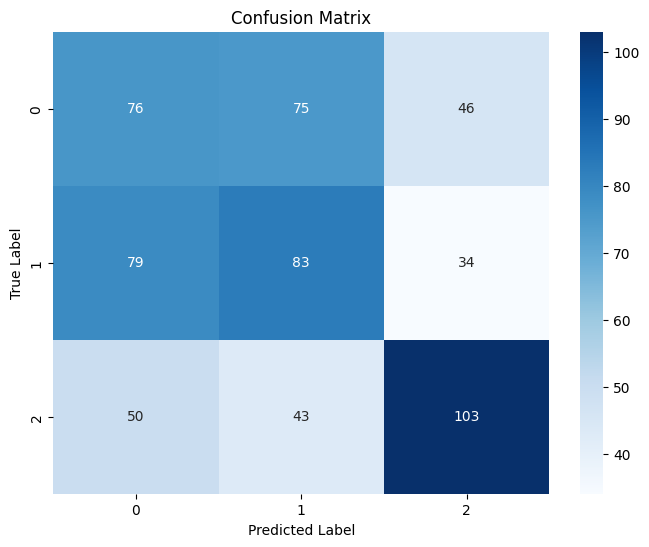

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

X_train = df_train.values.astype(np.float32)
y_train = df_train_labels["label"].values[::num_features].astype(np.int64)

X_val = df_val.values.astype(np.float32)
y_val = df_val_labels["label"].values[::num_features].astype(np.int64)

X_test = df_test.values.astype(np.float32)
y_test = df_test_labels["label"].values[::num_features].astype(np.int64)

# ✅ Ensure correct shape: (num_samples, 4 features, sequence_length)
sequence_length = 2 * CONTEXT + 1  # Each sample consists of `sequence_length` timestamps
num_features = num_features  # 4 Features per timestamp

X_train = X_train.reshape(-1, num_features, sequence_length)  # ✅ Now shape is (num_samples, 4, sequence_length)
X_val = X_val.reshape(-1, num_features, sequence_length)
X_test = X_test.reshape(-1, num_features, sequence_length)

print(X_train.shape)
print(y_train.shape)

# Define PyTorch Dataset
class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)  # No unsqueeze(1), we now have multiple features per timestamp
        self.y = torch.tensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataloaders
train_dataset = SignalDataset(X_train, y_train)
test_dataset = SignalDataset(X_test, y_test)
val_dataset = SignalDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model
model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)


# Training Loop
def train_model(model, train_loader, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Train Model
train_model(model, train_loader, num_epochs=10)

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Test the model and show confusion matrix
evaluate_model(model, test_loader)
